In [1]:
import gensim.downloader as api
from gensim.models import FastText, Word2Vec
from gensim.test.utils import common_texts
import numpy as np
import pandas as pd
import tensorflow.keras as keras
import tensorflow.keras.layers as L
import datasets
import re
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from gensim.utils import simple_tokenize
import fasttext
import fasttext.util

2026-04-03 23:57:57.468649: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-03 23:57:57.494966: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Part 1

In [2]:
words = [
    "dog",
    "bark",
    "tree",
    "bank",
    "river",
    "money"
]
glove = api.load("glove-twitter-50")
# The options provided in the assignment, `sentences=common texts, vector size=50, window=5, min count=1`,
# do not exist anywhere in gensim's documentation

In [3]:
fast_text = FastText(sentences=common_texts, vector_size=50, window=5, min_count=1, epochs=10)

## a) and b)

In [4]:
print("Glove:")
df = pd.DataFrame({
    w1: {
        w2: glove.similarity(w1, w2)
        for w2 in words
    }
    for w1 in words
})
print(df)
print()
print("FastText:")
df = pd.DataFrame({
    w1: {
        w2: fast_text.wv.similarity(w1, w2)
        for w2 in words
    }
    for w1 in words
})
print(df)
del df

Glove:
            dog      bark      tree      bank     river     money
dog    1.000000  0.593780  0.713751  0.348236  0.401201  0.575133
bark   0.593780  1.000000  0.545873  0.040109  0.266635  0.290985
tree   0.713751  0.545873  1.000000  0.349456  0.487116  0.510081
bank   0.348236  0.040109  0.349456  1.000000  0.319922  0.674656
river  0.401201  0.266635  0.487116  0.319922  1.000000  0.337800
money  0.575133  0.290985  0.510081  0.674656  0.337800  1.000000

FastText:
            dog      bark      tree      bank     river     money
dog    1.000000  0.107832 -0.169992  0.031316 -0.013496 -0.111240
bark   0.107832  1.000000  0.207565  0.169627  0.086654 -0.046768
tree  -0.169992  0.207565  1.000000  0.035650  0.065254 -0.263089
bank   0.031316  0.169627  0.035650  1.000000  0.203295 -0.016420
river -0.013496  0.086654  0.065254  0.203295  1.000000 -0.122650
money -0.111240 -0.046768 -0.263089 -0.016420 -0.122650  1.000000


In [5]:
del words, glove, fast_text

## c)

FastText did a better job of capturing semantics because it had a positive similarity between words that made sense together (e.g., dog was most similar to bark, river was most similar to bank, etc.). In addition, its similarity scores were negative for combinations that made less sense (e.g., dog and tree). The only exception is bank and money, which had a slight negaive similarity score. In glove, dog was most similar to tree (one could argue that this makes sense because they are both living things, but bark is a more relevant pairing), and river was most similar to tree. These less sensible pairings had low or negative similarities in FastText.

# Part 2

## Load Data

(And fix splits)

In [6]:
# Source: https://huggingface.co/datasets/cardiffnlp/tweet_eval#data-fields
EMOJIS = {
    0: "❤",
    1: "😍",
    2: "😂",
    3: "💕",
    4: "🔥",
    5: "😊",
    6: "😎",
    7: "✨",
    8: "💙",
    9: "😘",
    10: "📷",
    11: "🇺🇸",
    12: "☀",
    13: "💜",
    14: "😉",
    15: "💯",
    16: "😁",
    17: "🎄",
    18: "📸",
    19: "😜"
}

dataset = datasets.load_dataset("tweet_eval", "emoji")
print(f"Splits:\n{"\n".join(f"- {k.title()}: {len(v)}" for k, v in dataset.items())}")
print(f"- Total: {sum([len(v) for v in dataset.values()])}")
print()

# The given dataset has a 45% train, 50% test, 5% validation split.
# To get our 80/10/10% split, join everything and create the splits manually
dataset = datasets.concatenate_datasets(dataset.values())
split1 = dataset.train_test_split(train_size=0.8, seed=67)
split2 = split1["test"].train_test_split(test_size=0.5, seed=69) # 50% of the remaining 80% == 10%
dataset = datasets.DatasetDict({
    "train": split1["train"],
    "test": split2["train"],
    "validation": split2["test"]
})
del split1, split2
print(f"Splits:\n{"\n".join(f"- {k.title()}: {len(v)}" for k, v in dataset.items())}")
print(f"- Total: {sum([len(v) for v in dataset.values()])}")

Splits:
- Train: 45000
- Test: 50000
- Validation: 5000
- Total: 100000

Splits:
- Train: 80000
- Test: 10000
- Validation: 10000
- Total: 100000


## Preprocess

In [7]:
print("Removing urls...")
def remove_urls(x):
    x["text"] = re.sub(r'[-a-zA-Z0-9@:%._\+~#=]{1,256}\.[a-zA-Z0-9()]{1,6}\b([-a-zA-Z0-9()@:%_\+.~#?&//=]*)', "", x["text"])
    return x
dataset = dataset.map(remove_urls)

print("Removing special chars...")
def remove_special(x):
    ALLOWED = set(" abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ")
    out = ""
    for c in x["text"]:
        if c in ALLOWED:
            out += c
    x["text"] = out
    return x
dataset = dataset.map(remove_special)

print("One-hot encoding labels...")
def label_onehot(x):
    v = np.zeros(len(EMOJIS))
    v[x["label"]] = 1
    x["label"] = v
    return x
dataset = dataset.map(label_onehot)

print("Tokenizing...")
print("\tCreating vocab...")
def split_text(x):
    return x.lower().split(" ")
NUM_SPECIAL_TOKENS = 2 # pad + unk
PAD_TOKEN = "\0"
PAD_TOKEN_ID = 0
UNK_TOKEN = "<unk>"
UNK_TOKEN_ID = 1
VOCAB_SIZE = 5000
vocab = Counter(
    word
    for split in dataset.values()
    for row in split
    for word in split_text(row["text"])
)
print(f"\t\tTotal words: {len(vocab)}")
print(f"\t\tVocab size: {VOCAB_SIZE}")
top = sorted(vocab.keys(), key=vocab.get, reverse=True)[:VOCAB_SIZE - NUM_SPECIAL_TOKENS]
word_to_id = { w: i + NUM_SPECIAL_TOKENS for i, w in enumerate(top) }
word_to_id[PAD_TOKEN] = PAD_TOKEN_ID
word_to_id[UNK_TOKEN] = UNK_TOKEN_ID
del top
id_to_word = { i: w for w, i in word_to_id.items() }
def tokenize(x):
    x["text"] = np.array([word_to_id.get(w, UNK_TOKEN_ID) for w in split_text(x["text"])], dtype=np.int16)
    return x
dataset = dataset.map(tokenize)

print("Padding...")
print("\tDeterimining padding size...")
PAD_LENGTH = max([len(row["text"]) for split in dataset.values() for row in split])
print(f"\t\tPadded size = {PAD_LENGTH}")
def pad_text(x):
    # Add padding before the sequence because of https://arxiv.org/abs/1903.07288
    x["text"] = np.concatenate([
        np.full(PAD_LENGTH - len(x["text"]), PAD_TOKEN_ID, dtype=np.int16),
        x["text"]
    ])
    return x
dataset = dataset.map(pad_text)

Removing urls...


Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Removing special chars...


...

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Padding...
	Deterimining padding size...
		Padded size = 39


Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

### Convert to TensorFlow dataset

In [8]:
dataset = {
    split: dataset[split].to_tf_dataset(columns="text", label_cols="label", batch_size=32)
    for split in dataset.keys()
}

I0000 00:00:1775278725.507175  438400 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13360 MB memory:  -> device: 0, name: NVIDIA RTX 2000 Ada Generation, pci bus id: 0000:02:00.0, compute capability: 8.9


## Models

### Base Model

In [9]:
def train_base_model(epochs, dropout):
    model = keras.Sequential([
        L.Input(shape=(None,), dtype=np.int16),
        L.Embedding(VOCAB_SIZE, 50),
        L.LSTM(64, return_sequences=False),
        L.Dropout(dropout),
        L.Dense(len(EMOJIS), activation="softmax")
    ])
    optimizer = keras.optimizers.RMSprop(learning_rate=0.01)
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(dataset["train"], epochs=epochs, validation_data=dataset["validation"])
    return model, history

### FastText Model

In [10]:
# Official FastText models only come in 300D, but they provide a helper to convert to a lower dim
print("Downloading...")
fasttext.util.download_model("en", if_exists="ignore")
print("Loading...")
ft = fasttext.load_model("cc.en.300.bin")
print("Reducing dimension...")
ft = fasttext.util.reduce_model(ft, 50)
ft_embeddings = np.zeros((VOCAB_SIZE, 50))
for w, i in word_to_id.items():
    ft_embeddings[i] = ft.get_word_vector(w)

Downloading...
Loading...
Reducing dimension...


In [11]:
def train_ft_model(epochs, dropout):
    model = keras.Sequential([
        L.Input(shape=(None,), dtype=np.int16),
        L.Embedding(VOCAB_SIZE, 50, weights=[ft_embeddings], trainable=False),
        L.LSTM(64, return_sequences=False),
        L.Dropout(dropout),
        L.Dense(len(EMOJIS), activation="softmax")
    ])
    optimizer = keras.optimizers.RMSprop(learning_rate=0.01)
    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(dataset["train"], epochs=epochs, validation_data=dataset["validation"])
    return model, history

## Analysis

In [12]:
def analyze_model(kind, epochs, dropout):
    print(f"Training {kind} model for {epochs} epochs with dropout={dropout}")
    model, history = {
        "base": train_base_model,
        "ft": train_ft_model
    }[kind](epochs, dropout)
    _, v_accuracy = model.evaluate(dataset["validation"])
    return {
        "model": model,
        "kind": kind,
        "epochs": epochs,
        "dropout": dropout,
        "train_loss": history.history["loss"][-1],
        "test_accuracy": history.history["val_accuracy"][-1],
        "validation_accuracy": v_accuracy,
        "loss_curve": list(zip(history.history["loss"], history.history["val_loss"])),
    }

models = [
    analyze_model(kind, epochs, dropout)
    for kind in ["base", "ft"]
    for epochs in [3, 5, 10]
    for dropout in [0.2, 0.3, 0.5]
]

Training base model for 3 epochs with dropout=0.2
Epoch 1/3


2026-04-03 23:58:53.182035: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.3120 - loss: 2.3553 - val_accuracy: 0.3577 - val_loss: 2.2067
Epoch 2/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3659 - loss: 2.1758 - val_accuracy: 0.3657 - val_loss: 2.1810
Epoch 3/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3865 - loss: 2.1019 - val_accuracy: 0.3645 - val_loss: 2.2097
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3645 - loss: 2.2097
Training base model for 3 epochs with dropout=0.3
Epoch 1/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3087 - loss: 2.3700 - val_accuracy: 0.3564 - val_loss: 2.2111
Epoch 2/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3637 - loss: 2.1950 - val_accuracy: 0.3576 - val_loss: 2.2018
Epoch 3/3
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3829 - loss: 2.1317 - val_accuracy: 0.3609 - val_loss: 2.2116
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3609 - loss: 2.2116
Training base model for 3 epochs wit

### Data and Graphs

Model analysis table:
    kind  epochs  dropout  train_loss  test_accuracy  validation_accuracy
0   base       3      0.2    2.101949         0.3645               0.3645
1   base       3      0.3    2.131689         0.3609               0.3609
2   base       3      0.5    2.183995         0.3620               0.3620
3   base       5      0.2    2.010757         0.3499               0.3499
4   base       5      0.3    2.053836         0.3591               0.3591
5   base       5      0.5    2.143487         0.3522               0.3522
6   base      10      0.2    1.947565         0.3443               0.3443
7   base      10      0.3    2.015034         0.3462               0.3462
8   base      10      0.5    2.151026         0.3436               0.3436
9     ft       3      0.2    2.238934         0.3433               0.3433
10    ft       3      0.3    2.268000         0.3445               0.3445
11    ft       3      0.5    2.366249         0.3370               0.3370
12    ft       5

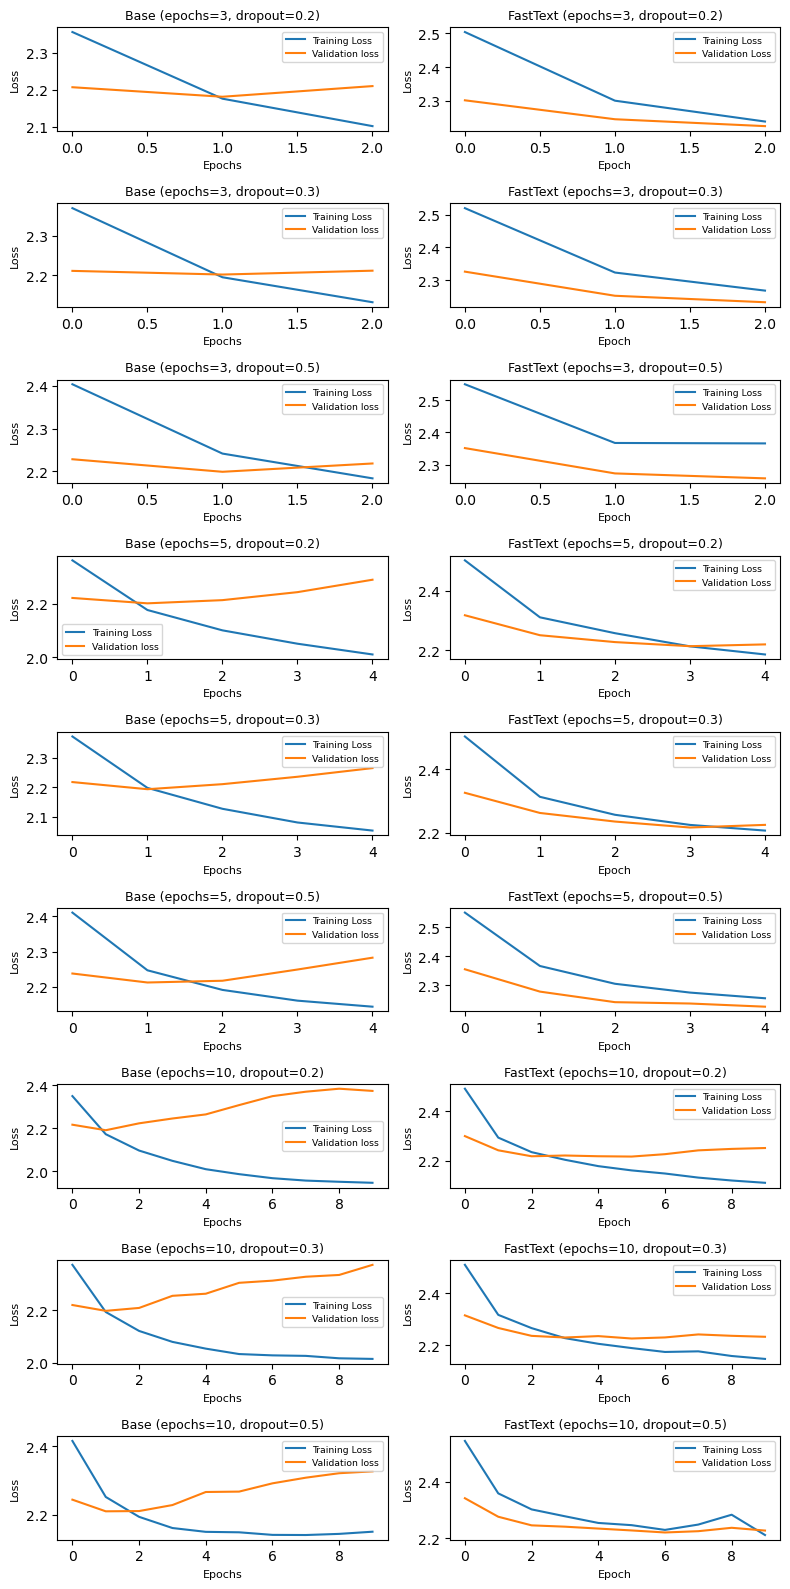

In [13]:
print("Model analysis table:")
print(pd.DataFrame(models).drop(columns=["loss_curve", "model"]))
print("\n\n")

groups = defaultdict(dict)
for model in models:
    groups[(model["epochs"], model["dropout"])][model["kind"]] = model

_, axes = plt.subplots(9, 2, figsize=(8, 16))
for row, (epochs, dropout) in enumerate(sorted(groups.keys())):
    g = groups[(epochs, dropout)]

    train_loss, val_loss = zip(*g["base"]["loss_curve"])
    ax = axes[row, 0]
    ax.plot(train_loss, label="Training Loss")
    ax.plot(val_loss, label="Validation loss")
    ax.set_title(f"Base (epochs={epochs}, dropout={dropout})", fontsize=9)
    ax.set_xlabel("Epochs", fontsize=8)
    ax.set_ylabel("Loss", fontsize=8)
    ax.legend(fontsize=6.7)

    train_loss, val_loss = zip(*g["ft"]["loss_curve"])
    ax = axes[row, 1]
    ax.plot(train_loss, label="Training Loss")
    ax.plot(val_loss, label="Validation Loss")
    ax.set_title(f"FastText (epochs={epochs}, dropout={dropout})", fontsize=9)
    ax.set_xlabel("Epoch", fontsize=8)
    ax.set_ylabel("Loss", fontsize=8)
    ax.legend(fontsize=6.7)

plt.tight_layout()
plt.show()
del axes

### Convergence Notes

Most of the models overfit, except FastText with $3$ epochs and $0.3$ dropout, $3$ epochs and $0.5$ dropout, and $5$ epochs and $5$ dropout

### Best Hyperparameters

Base: all of them overfit, but the model with $3$ epochs and $0.5$ dropout overfit the least. The best base model had $3$ epochs and $0.2$ dropout for the best validation accuracy

FastText: using $10$ epochs with $0.2$ dropout values was the best in validation accuracy.

### Best Embeddings

The base model had better accuracy, but it overfit more than FastText.

### Performance

The best performance was achieved with $3$ epochs, even though increasing them also increased loss.

### Comparison of misclassifications

In [14]:
def decode_text(x):
    out = []
    for t in x:
        if t == PAD_TOKEN_ID:
            continue
        out.append(id_to_word.get(int(t), UNK_TOKEN))
    return " ".join(out)

def find_examples(model, split, n=5):
    incorrect = []
    for x_batch, y_batch in split:
        preds = model.predict(x_batch, verbose=0)
        pred_labels = np.argmax(preds, axis=1)
        true_labels = np.argmax(y_batch.numpy(), axis=1)
        for i in range(len(pred_labels)):
            text = decode_text(x_batch[i].numpy())
            pred = pred_labels[i]
            true = true_labels[i]
            if pred != true:
                if len(incorrect) < n:
                    incorrect.append({
                        "text": text,
                        "true": EMOJIS[true],
                        "pred": EMOJIS[pred]
                    })
                else:
                    break
        if len(incorrect) >= n:
            break
    return incorrect

for m in models:
    print(f"Model kind={m['kind']}, epochs={m['epochs']}, dropout={m['dropout']}")

    incorrect = find_examples(m["model"], dataset["test"])
    for ex in incorrect:
        print(f"\t{ex['text']}")
        print(f"\t\tTrue: {ex['true']} | Predicted: {ex['pred']}")

    print()

Model kind=base, epochs=3, dropout=0.2
	always love boxing with my clients to give that extra push <unk>
		True: 💯 | Predicted: ❤
	tbt <unk> <unk> <unk>  university bowl
		True: 😂 | Predicted: 😍
	its santa oh my god i know him <unk> user
		True: 🎄 | Predicted: 😍
	ran out of cream at home but <unk> always has plenty at user in sunnyvale ca
		True: 💜 | Predicted: 😍
	celebrating  years of love amp happiness i love you more than words
		True: 💕 | Predicted: ❤

Model kind=base, epochs=3, dropout=0.3
	always love boxing with my clients to give that extra push <unk>
		True: 💯 | Predicted: ❤
	tbt <unk> <unk> <unk>  university bowl
		True: 😂 | Predicted: 😍
	its santa oh my god i know him <unk> user
		True: 🎄 | Predicted: 😂
	ran out of cream at home but <unk> always has plenty at user in sunnyvale ca
		True: 💜 | Predicted: 😊
	celebrating  years of love amp happiness i love you more than words
		True: 💕 | Predicted: ❤

Model kind=base, epochs=3, dropout=0.5
	always love boxing with my clients to 